# Dimension Reduction, PCA & PCR — Homework Assignment

## Course: Business Analytics with R

**Total Points: 100**

### Instructions
1. Complete all tasks by writing R code in the provided cells
2. Run each cell to verify your code works correctly
3. Comment your code to explain your reasoning
4. Show your output — do not suppress results
5. Answer all interpretation questions in comments or markdown

### Skills Tested
- Data loading, inspection, and missing value checks
- Normalization / standardization (`scale()`)
- Correlation analysis and visualization
- Principal Component Analysis (PCA) — scree plots, loadings, biplots
- Component interpretation and naming
- Principal Component Regression (PCR) — fitting, cross-validation, prediction
- RMSE evaluation

### Datasets
All data files are in the `data/module_3/` folder of this repository:
- **PCA:** `PCA_Protein_data.csv` (European protein consumption by country)
- **PCR:** `PCR_TRAIN DATA.csv` and `PCR_TEST DATA.csv` (spectrometric readings)

**Data Path Hint:** Use `read.csv("../data/module_3/FILENAME.csv", header = TRUE)` to load files from this Homework folder.

---

## Setup: Load Required Libraries

Run this cell first to load all necessary packages.

In [1]:
# Load required libraries
library(corrr)
library(ggcorrplot)
library(FactoMineR)
library(factoextra)
library(pls)

Loading required package: ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


Attaching package: ‘pls’


The following object is masked from ‘package:stats’:

    loadings




---

## Part 1: Data Exploration & Preparation (20 points)

Before running PCA, we need to understand and prepare the data.

### Task 1.1: Load and Inspect the Protein Data (5 points)

Load `PCA_Protein_data.csv` from the `data/module_3/` folder. Store it in a variable called `protein`. Display the first 6 rows.

In [ ]:
# Load the data
protein <- read.csv("/workspaces/MS3313-FryeV2/data/module_3/PCA_Protein_data.csv")
# Display the data
head(protein, 6)

,Country,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
2,Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
3,Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
4,Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
5,Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0
6,Denmark,10.6,10.8,3.7,25.0,9.9,21.9,4.8,0.7,2.4


### Task 1.2: Check for Missing Values (5 points)

Check whether the dataset has any missing values. Display the total number of NAs across the entire dataset.

In a comment, explain: **Why is it important to check for missing values before running PCA?**

In [ ]:
# check for missing values
sum(is.na(protein))

# missing values can skew the data, give incorrect results,
# or potentially cause functions to fail

[1] 0

### Task 1.3: Normalize the Data (5 points)

Use `scale()` to standardize only the **numeric columns** (columns 2 through 10 — exclude the Country name column). Store the result in `protein_scaled`.

In a comment, explain: **Why do we need to normalize before PCA? What would happen if one variable was measured in grams and another in kilograms?**

In [ ]:
#normalize the data
protein_scaled <- scale(protein[, 2:10])

# We need to normalize data because if we dont some data can completely dominate others.
# The variable in kilograms would dominate the variable in grams. Normalizing causes that to not happen.

### Task 1.4: Correlation Matrix (5 points)

1. Compute the correlation matrix for the scaled data
2. Visualize it using `ggcorrplot()`

In a comment, identify: **Which two food categories have the strongest positive correlation? Which two have the strongest negative correlation?**

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.”


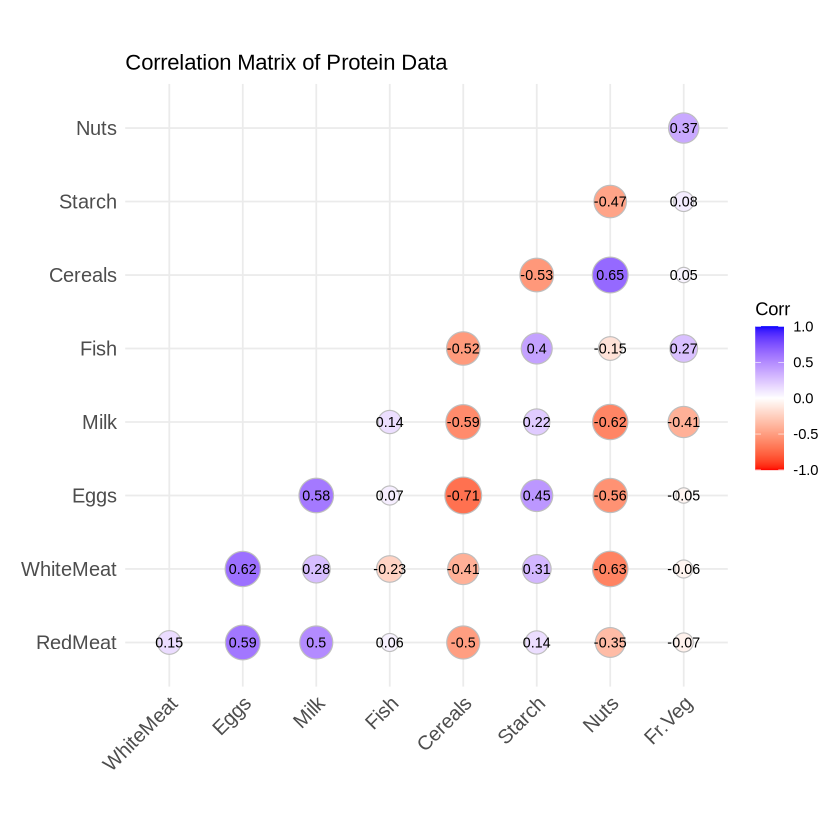

In [ ]:
# turn data into a correlation matrix
cor_matrix <- cor(protein_scaled)
# visualize the data with ggcorplot()
ggcorrplot(cor_matrix,
           method = "circle",
           type = "lower",
           lab = TRUE,
           lab_size = 3,
           colors = c("red", "white", "blue"),
           title = "Correlation Matrix of Protein Data",
           ggtheme = theme_minimal())

# The strongest positive is cereals and nuts
# The strongest negative is Eggs and Cereals

---

## Part 2: Principal Component Analysis (40 points)

Now we'll run PCA and interpret the results.

### Task 2.1: Run PCA (5 points)

Perform PCA on the scaled protein data using the `PCA()` function from FactoMineR. Store the result in `protein_pca`. Use `graph = FALSE` to suppress automatic plots for now.

In [ ]:
# use PCA function to perform PCA on the scaled data
protein_pca <- PCA(protein_scaled, graph = FALSE)

### Task 2.2: Scree Plot (5 points)

Create a scree plot using `fviz_screeplot()` to visualize the variance explained by each component.

In a comment, answer: **How many components would you retain, and why? Reference the elbow method and/or the 70–90% cumulative variance rule.**

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


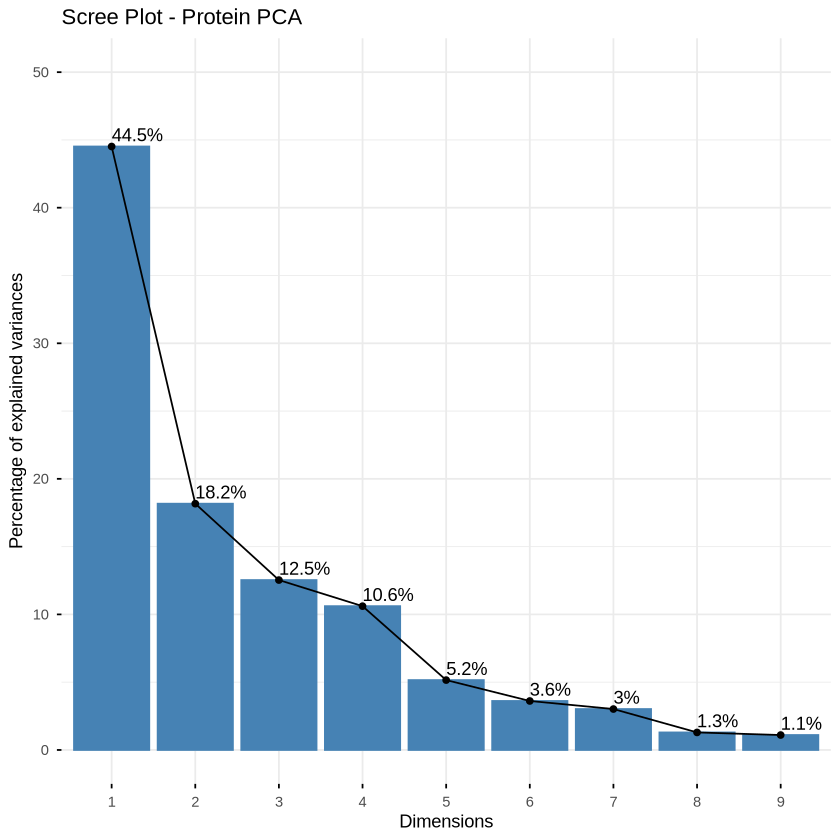

In [ ]:
# use fviz_screeplot() to create a plot and visualize the data
fviz_screeplot(protein_pca,
               addlabels = TRUE,
               ylim = c(0, 50),
               title = "Scree Plot - Protein PCA")
# I would keep 4 variables, as that is where the elbow flattens out.

### Task 2.3: View the Loadings (5 points)

Display the PCA summary to see the loadings. You can access this from the PCA result object.

**Hint:** Use `summary(protein_pca)` or examine `protein_pca$var$coord` for the variable coordinates.

In [ ]:
# show the pca results
summary(protein_pca)
# show the loadings for the variables
protein_pca$var$coord


Call:
PCA(X = protein_scaled, graph = FALSE) 


Eigenvalues
                       Dim.1   Dim.2   Dim.3   Dim.4   Dim.5   Dim.6   Dim.7
Variance               4.006   1.635   1.128   0.955   0.464   0.325   0.272
% of var.             44.516  18.167  12.532  10.607   5.154   3.613   3.018
Cumulative % of var.  44.516  62.683  75.215  85.822  90.976  94.589  97.607
                       Dim.8   Dim.9
Variance               0.116   0.099
% of var.              1.292   1.101
Cumulative % of var.  98.899 100.000

Individuals (the 10 first)
              Dist    Dim.1    ctr   cos2    Dim.2    ctr   cos2    Dim.3
1         |  4.547 | -3.557 12.634  0.612 | -1.664  6.775  0.134 | -1.798
2         |  2.498 |  1.452  2.105  0.338 | -1.063  2.763  0.181 |  1.365
3         |  1.966 |  1.655  2.736  0.709 |  0.163  0.065  0.007 |  0.221
4         |  3.717 | -3.199 10.215  0.741 | -1.328  4.314  0.128 |  0.154
5         |  1.771 |  0.378  0.143  0.046 | -0.615  0.926  0.121 |  1.221
6         |

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5
RedMeat,0.6057056,-0.07192736,-0.31604009,0.631652227,0.21940932
WhiteMeat,0.6216121,-0.30285749,0.66260104,-0.036144004,-0.20442938
Eggs,0.8540434,-0.04518280,0.19278949,0.305982733,0.05387873
Milk,0.7560622,-0.23602830,-0.40958221,-0.003242188,-0.13649306
Fish,0.2715180,0.82706958,-0.34120473,-0.211002952,-0.19752735
Cereals,-0.8761911,-0.29855059,0.10186779,-0.006061851,0.16220583
Starch,0.5949735,0.45114790,0.25804812,-0.328964239,0.50123965
Nuts,-0.8413450,0.18324705,-0.05776175,0.322713744,0.10252418
Fr.Veg,-0.2210174,0.68561064,0.43283909,0.451460378,-0.15903812


### Task 2.4: Interpret and Name the Components (10 points)

Look at the loadings for **PC1** and **PC2**. For each component:
1. List the food categories with the **strongest loadings** (|loading| > 0.4)
2. Note whether they are positive or negative
3. Give the component a **descriptive business-friendly name** based on the pattern you see

Write your answers as comments below. For example: *"PC1 has high positive loadings on Milk and Eggs, so I would call it 'Dairy & Animal Products Dimension.'"*

In [ ]:
# YOUR INTERPRETATION HERE (as comments)
#
# PC1 Name: Dairy and Animal Products Dimension
# Strong loadings: 
# Red Meat - Positive -> High Red Meat Consumption
# Eggs - Positive -> High Eggs Consumption
# Milk - Positive -> High Milk Consumption
# Starch - Positive -> High Starch Consumption
# Cereals - Negative -> Low Cereal Consumption
# Nuts - Negative -> Low Nuts Consumption
# PC1 Shows places that have a very high Dairy and Animal product consumption,
# and low plant based product consumption.
# 
# PC2 Name: Fish and Plant based Dimension
# Strong loadings: 
# Fish - Positive -> High Fish Consumption
# Starch - Positive -> High Starch Consumption
# Fr. Veg - Positive -> High Fresh Vegetable Consumption
# PC2 Shows places that have a very high Fish and Plant based diet,
# and low land based meat consumption.

### Task 2.5: Biplot (5 points)

Create a biplot using `fviz_pca_var()` to visualize the variable relationships.

In a comment, answer: **Which food categories point in the same direction (positively correlated)? Are any pointing in opposite directions (negatively correlated)?**

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”


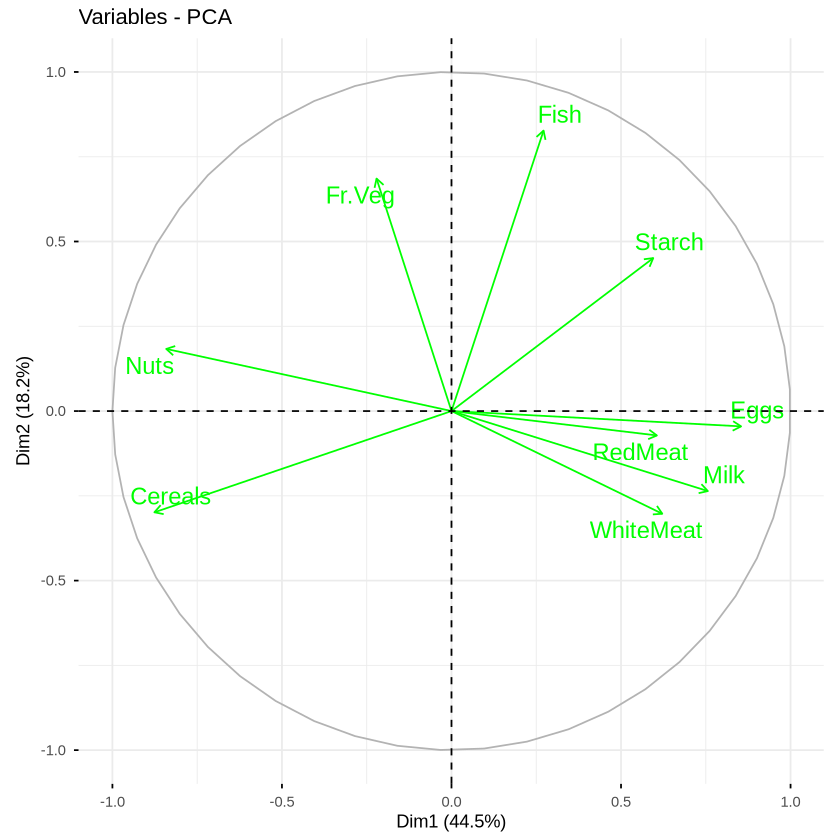

In [ ]:
# create the biplot using fviz_pca_var()
p <- fviz_pca_var(protein_pca, col.var = "green", repel = TRUE, labelsize = 5)
# show the biplot picture
tmp <- tempfile(fileext = ".png")
ggsave(tmp, plot = p, width = 8, height = 6, dpi = 150)
print(p)

### Task 2.6: Cos² Chart (5 points)

Create a Cos² bar chart using `fviz_cos2()` for the first two components (`axes = 1:2`).

In a comment, answer: **Which food categories are well-represented by the first two components (high Cos²)? Are any poorly represented?**

In [ ]:
# create the cos^2 bar chart
p <- fviz_cos2(protein_pca, choice = "var", axes = 1:2)
# save the chart picture so we can view it
ggsave("cos2_plot.png", plot = p, width = 12, height = 8, dpi = 150)
# Not sure how to open it in here like you showed us, this is all i could get

### Task 2.7: Business Application Question (5 points)

Imagine you work for an international food company expanding into Europe. Based on your PCA results, answer the following in a comment:

1. If a country scores high on PC1, what does that tell you about its diet?
2. How could you use these principal components to **group countries** for a marketing strategy?
3. Why is PCA more useful here than just looking at all 9 food variables separately?

In [ ]:
# 1.
# IF a country scores high on PC1, they likely have a more western style diet.
# They also are probably more of an inland country that doesn't have a strong
# fishing economy. They also have a very low consumption of plant-based foods
# like cereals and nuts.

# 2.
# For high PC1 countries, market more of the meats and dairy.
# For high PC2 countries, market more of the seafood and plants.

# 3.
# Without PCA we would have to analyze all 36 possible correlations,
# instead we have a more straightforward way that gives us 2 super
# variables that allow us to visualize patterns and group countries 
# which allows us to market better to those people.

---

## Part 3: Principal Component Regression (40 points)

PCR combines PCA with regression — useful when your predictors are correlated.

### Task 3.1: Load the PCR Data (5 points)

Load both `PCR_TRAIN DATA.csv` and `PCR_TEST DATA.csv` from the `data/module_3/` folder. Store them as `pcr_train` and `pcr_test`. Display the dimensions and first few rows of the training set.

In [ ]:
# load the data
pcr_train <- read.csv("/workspaces/MS3313-FryeV2/data/module_3/PCR_TRAIN DATA.csv")
pcr_test  <- read.csv("/workspaces/MS3313-FryeV2/data/module_3/PCR_TEST DATA.csv")
# display the dimensions and the first few rows
dim(pcr_train)
dim(pcr_test)
head(pcr_train)

[1] 18 37

[1] 15 37

,obsnam,tot,tyr,f1,f2,f3,f4,f5,f6,f7,⋯,f25,f26,f27,f28,f29,f30,try,tyr_log,try_log,tot_log
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,17mix35,3e-05,0.0e+00,-6.215,-5.809,-5.114,-3.963,-2.897,-2.269,-1.675,⋯,-1.520,-1.804,-2.044,-2.269,-2.496,-2.714,3.000e-05,-8.000000,-4.522879,-4.522879
2,19mix35,3e-05,3.0e-07,-5.516,-5.294,-4.823,-3.858,-2.827,-2.249,-1.683,⋯,-1.541,-1.814,-2.058,-2.289,-2.496,-2.712,2.970e-05,-6.522879,-4.527244,-4.522879
3,21mix35,3e-05,7.5e-07,-5.519,-5.294,-4.501,-3.863,-2.827,-2.280,-1.716,⋯,-1.565,-1.841,-2.084,-2.320,-2.521,-2.729,2.925e-05,-6.124939,-4.533874,-4.522879
4,23mix35,3e-05,1.5e-06,-5.294,-4.705,-4.262,-3.605,-2.726,-2.239,-1.681,⋯,-1.579,-1.852,-2.090,-2.316,-2.521,-2.743,2.850e-05,-5.823909,-4.545155,-4.522879
5,25mix35,3e-05,3.0e-06,-4.600,-4.069,-3.764,-3.262,-2.598,-2.191,-1.680,⋯,-1.619,-1.886,-2.141,-2.359,-2.585,-2.792,2.700e-05,-5.522879,-4.568636,-4.522879
6,27mix35,3e-05,7.5e-06,-3.812,-3.376,-3.026,-2.726,-2.249,-1.919,-1.541,⋯,-1.784,-2.058,-2.297,-2.507,-2.727,-2.970,2.250e-05,-5.124939,-4.647817,-4.522879


### Task 3.2: Check Predictor Correlations (5 points)

Compute and display the correlation matrix for columns `f1` through `f10` in the training data.

In a comment, answer: **Are the predictors correlated? Why does this make standard regression a poor choice?**

In [ ]:
# compute the correlation matrix
cor_matrix <- cor(pcr_train[, c("f1","f2","f3","f4","f5","f6","f7","f8","f9","f10")])
# print the matrix
print(round(cor_matrix, 2))

# Yes the predictors are correlated, which makes standard regression a bad
# choice because of multicollinearity concerns. This causes the variance to be
# inflated artifically.

       f1    f2    f3    f4    f5   f6   f7    f8    f9   f10
f1   1.00  1.00  0.99  0.97  0.91 0.67 0.12 -0.29 -0.47 -0.54
f2   1.00  1.00  1.00  0.97  0.91 0.68 0.15 -0.27 -0.44 -0.52
f3   0.99  1.00  1.00  0.99  0.94 0.73 0.21 -0.22 -0.40 -0.48
f4   0.97  0.97  0.99  1.00  0.98 0.81 0.31 -0.14 -0.33 -0.43
f5   0.91  0.91  0.94  0.98  1.00 0.91 0.48  0.04 -0.17 -0.27
f6   0.67  0.68  0.73  0.81  0.91 1.00 0.80  0.45  0.24  0.13
f7   0.12  0.15  0.21  0.31  0.48 0.80 1.00  0.89  0.77  0.69
f8  -0.29 -0.27 -0.22 -0.14  0.04 0.45 0.89  1.00  0.97  0.94
f9  -0.47 -0.44 -0.40 -0.33 -0.17 0.24 0.77  0.97  1.00  0.99
f10 -0.54 -0.52 -0.48 -0.43 -0.27 0.13 0.69  0.94  0.99  1.00


### Task 3.3: Fit a PCR Model (5 points)

Fit a PCR model predicting `tot_log` from `f1` through `f10` using the training data. Use `scale = TRUE` and `validation = "CV"` for 10-fold cross-validation.

Display the model summary.

In [ ]:
library(pls)

# fit the PCR model
pcr_model <- pcr(tot_log ~ f1 + f2 + f3 + f4 + f5 + f6 + f7 + f8 + f9 + f10,
                 data       = pcr_train,
                 scale      = TRUE,
                 validation = "CV")   # 10-fold cross-validation
# display the PCR model
summary(pcr_model)

Data: 	X dimension: 18 10 
	Y dimension: 18 1
Fit method: svdpc
Number of components considered: 10

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           0.248   0.2647  0.06618  0.05827  0.06368  0.06012  0.06164
adjCV        0.248   0.2644  0.06560  0.05721  0.06237  0.05854  0.06008
       7 comps  8 comps  9 comps  10 comps
CV     0.06379  0.07033  0.08559    0.1330
adjCV  0.06191  0.06800  0.08228    0.1266

TRAINING: % variance explained
         1 comps  2 comps  3 comps  4 comps  5 comps  6 comps  7 comps  8 comps
X         59.399    98.39    99.88    99.95    99.98    99.99   100.00   100.00
tot_log    3.624    94.86    97.05    97.06    97.68    97.68    97.96    98.04
         9 comps  10 comps
X         100.00    100.00
tot_log    98.06     98.11


### Task 3.4: Validation Plot (5 points)

Create a validation plot using `validationplot()` with `val.type = "RMSEP"` to visualize cross-validation error by number of components.

In a comment, answer: **How many components would you select? Why?**

In [ ]:
# create the picture for the plot
png("validation_plot.png", width = 800, height = 600)
# create the plot
validationplot(pcr_model, val.type = "RMSEP")
dev.off()

# I would select 4 components since thats where the elbow is

agg_record_1826929084 
                    2

### Task 3.5: Make Predictions (5 points)

Using your chosen number of components (use `ncomp = 4`), predict `tot_log` on the **test** data. Store the predictions in a variable called `pcr_pred`.

In [ ]:
# make a prediction using the 4 components
pcr_pred <- predict(pcr_model, newdata = pcr_test, ncomp = 4)


### Task 3.6: Calculate RMSE (5 points)

Calculate the Root Mean Square Error (RMSE) on the test set by comparing your predictions to the actual `tot_log` values.

**Formula:** `RMSE = sqrt(mean((actual - predicted)^2))`

Also calculate `RMSE / mean(actual)` to get a percentage — this tells you how large the error is relative to the average value.

In [ ]:
# Calculate RMSE
actual <- pcr_test$tot_log
rmse_test <- sqrt(mean((actual - pcr_pred)^2))
# Print results
cat("Test RMSE with 4 components:", rmse_test)

Test RMSE with 4 components: 0.0462024

### Task 3.7: Interpret Your Results (5 points)

Answer the following in comments:

1. Is the RMSE acceptable? (Refer to the RMSE/Mean percentage — under 20% is good)
2. Why did we use PCR instead of regular regression for this dataset?
3. Give one real-world business example where you'd face the same problem (correlated predictors) and use PCR to solve it

In [ ]:
# 1.
# Yes the RMSE is acceptable (.046)

# 2. 
# The predictors were highly correlated, so we use PCR
# because it converts it to uncorrelated components before regressing

# 3.
# Phone company has components like "number of calls", 
# "number of texts", "time spent on call", and high volume users
# have elevated stats in all of them. PCR would solve this by
# creating a component called "overall usage" which solves the
# multicollinearity issue

### Task 3.8: When to Use What? (5 points)

In comments below, briefly explain the difference between PCA and PCR. When would you use each one? Fill in the blanks:

- "I would use **PCA** when my goal is to ____________________"
- "I would use **PCR** when my goal is to ____________________"
- "The key difference is that PCA is __________ while PCR is __________"

In [ ]:
# YOUR ANSWERS HERE (as comments)
#
# I would use PCA when my goal is to reduce dimensionality of data
# I would use PCR when my goal is to predict a response using correlated components
# The key difference is that PCA is unsupervised while PCR is supervised

---

## Submission Checklist

Before submitting, verify:

- [ ] All cells run without errors
- [ ] All tasks have been attempted
- [ ] Code includes comments explaining your approach
- [ ] Interpretation questions are answered in comments
- [ ] Output is visible (not suppressed)

**Good luck!**